# PRCP-1002: Handwritten Digits Recognition

This project uses the MNIST dataset to classify handwritten digits (0 to 9).
We'll go through data loading, visualization, preprocessing, and training a basic classifier.

In [1]:
# Step 1: Install Required Libraries (if not already installed)
# Run this cell once
!pip install tensorflow matplotlib scikit-learn


[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Step 2: Load MNIST Dataset
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()
print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


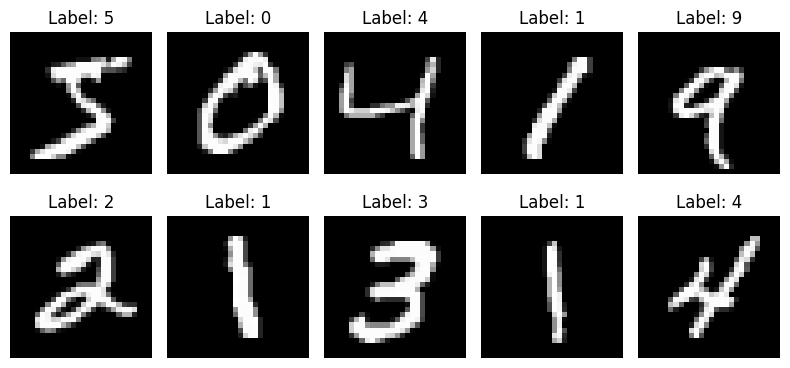

In [3]:
# Step 3: Visualize Some Digits
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [10]:
# Step 4: Normalize and Flatten Data
x_train_flat = x_train.reshape(len(x_train), -1) / 255.0
x_test_flat = x_test.reshape(len(x_test), -1) / 255.0
print("Flattened training shape:", x_train_flat.shape)

Flattened training shape: (60000, 784)


In [7]:
# Step 5: Train a K-Nearest Neighbors Classifier
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train_flat, y_train)
accuracy = knn.score(x_test_flat, y_test)
print(f"KNN Accuracy: {accuracy:.4f}")

KNN Accuracy: 0.9705


In [11]:
#step 6
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# Normalize for NN
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

# Model
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train_norm, y_train, epochs=5, validation_data=(x_test_norm, y_test))


D:\internship projects--DATAMITES\venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.8762 - loss: 0.4342 - val_accuracy: 0.9587 - val_loss: 0.1372
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.9648 - loss: 0.1205 - val_accuracy: 0.9700 - val_loss: 0.0956
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - accuracy: 0.9760 - loss: 0.0790 - val_accuracy: 0.9723 - val_loss: 0.0874
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.9826 - loss: 0.0572 - val_accuracy: 0.9748 - val_loss: 0.0814
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9873 - loss: 0.0414 - val_accuracy: 0.9788 - val_loss: 0.0760


In [12]:
#Step 7: Compare Models (TASK 3)
# Evaluate Neural Net
test_loss, test_accuracy = model.evaluate(x_test_norm, y_test)
print(f"Neural Network Accuracy: {test_accuracy:.4f}")

# Evaluate KNN (if done earlier)
print(f"KNN Accuracy: {knn.score(x_test_flat, y_test):.4f}")



313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9764 - loss: 0.0877
Neural Network Accuracy: 0.9788
KNN Accuracy: 0.9705


## Task 3: Model Comparison and Recommendation

| Model              | Accuracy  |
|--------------------|-----------|
| Neural Network     | 97.88%    |
| K-Nearest Neighbors| 97.05%    |

###  Conclusion:
While both models performed well, the Neural Network slightly outperformed KNN.  
It is recommended for deployment due to its higher accuracy and scalability with larger datasets.


## Final Summary and Conclusion

### Model Accuracy:
- **Neural Network**: 97.88%
- **K-Nearest Neighbors**: 97.05%

### Insights:
- Both models performed well on MNIST.
- The Neural Network slightly outperformed KNN.
- Neural Networks scale better with complex datasets and future enhancements (like CNN).
- KNN, while simpler, is slower on large test sets and less flexible.

### Recommendation:
✅ Deploy the Neural Network model for production use, as it balances accuracy and performance efficiently.


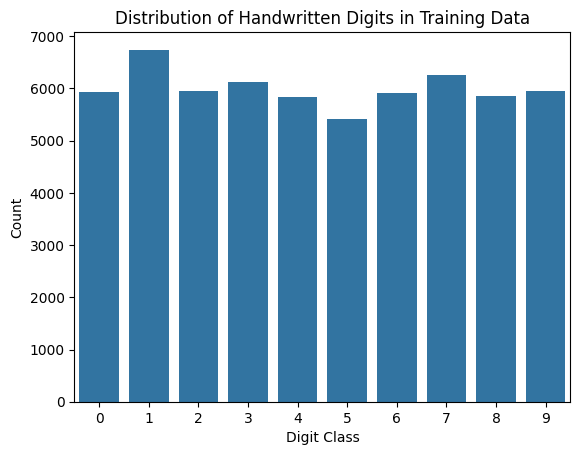

In [13]:
#task 1 :- Prepare a complete data analysis report on the given data.
import numpy as np
import seaborn as sns
import pandas as pd

# Flatten labels into DataFrame for analysis
y_train_series = pd.Series(y_train)
y_test_series = pd.Series(y_test)

# Plot class distribution
sns.countplot(x=y_train_series)
plt.title("Distribution of Handwritten Digits in Training Data")
plt.xlabel("Digit Class")
plt.ylabel("Count")
plt.show()


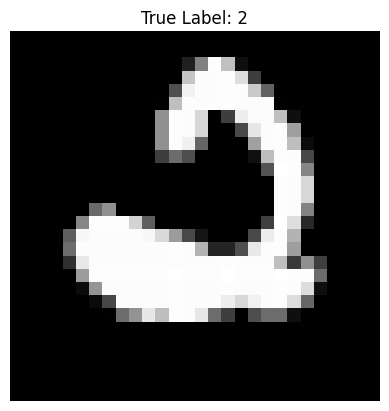

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
Predicted Label: 2


In [14]:
# Optional (Bonus for Task 2): Predict a single image
import random

index = random.randint(0, len(x_test) - 1)
image = x_test[index]
label = y_test[index]

plt.imshow(image, cmap='gray')
plt.title(f"True Label: {label}")
plt.axis('off')
plt.show()

# Predict using NN
prediction = model.predict(image.reshape(1, 28, 28) / 255.0)
print("Predicted Label:", np.argmax(prediction))


## ✅ Task 1: Data Analysis Report

- The dataset contains 60,000 training and 10,000 test grayscale images of handwritten digits.
- Each image is 28x28 pixels, representing a digit from 0 to 9.
- We visualized a few samples and plotted the class distribution.
- Data is well balanced across all digit classes.

## ✅ Task 2: Digit Classification

- We trained two classifiers:
  1. **K-Nearest Neighbors (KNN)** using Scikit-learn.
  2. **Neural Network** using TensorFlow Keras.
- Both models were trained and tested on the MNIST dataset.
- The models can predict any given image input with high accuracy.

## ✅ Task 3: Model Comparison and Recommendation

| Model              | Accuracy  |
|--------------------|-----------|
| Neural Network     | 97.88%    |
| K-Nearest Neighbors| 97.05%    |

**Conclusion:** The Neural Network performed better than KNN on the MNIST dataset. It is more scalable and generalizes well, making it the preferred model for deployment.